In [4]:
import pandas as pd
import numpy as np


# ============================================================
# НАСТРОЙКИ
# ============================================================

INPUT_FILE = r"C:\Users\user\Desktop\НКТЭЦ ГТ1 1+2 квартальный 2026.xlsx"
SHEET_NAME = "Данные"

EXPORT_FILE = "pair_export.xlsx"

LOW_POWER = 10

# 7 суток × 48 записей/сутки
GAP_SIZE = 7 * 48

# 24 часа = 48 записей
WORK_CONFIRM_SIZE = 48

# Окна анализа
WINDOW_SIZE = 48           # одно окно = 48 записей = 1 сутки
DAYS_ZONE = 10             # желаемый размер зоны по умолчанию
ZONE_SIZE = 48 * DAYS_ZONE # 480 записей

# Допуски
K_TOLERANCE = 0.05
B_TOLERANCE = 0.05

# Сколько лучших вариантов выгружать для каждого периода
TOP_N_EXPORT = 3


# ============================================================
# ПОИСК КОЛОНОК ПО ЗАГОЛОВКАМ
# ============================================================

def normalize_header(value):
    if pd.isna(value):
        return ""

    value = str(value).strip()
    value = value.split(",", 1)[0]
    return value.strip()


COLUMN_ALIASES = {
    "date": ["Дата", "дата"],
    "power": ["Nприв"],
    "fuel": ["Bприв", "Bприв, нм3/ч", "Расход газа"],
}


def find_column(columns, aliases, parameter_name):
    normalized_columns = {}

    for col in columns:
        normalized = normalize_header(col)
        if normalized:
            normalized_columns[col] = normalized

    for original_col, normalized_col in normalized_columns.items():
        if normalized_col in aliases:
            return original_col

    raise ValueError(
        f"\nНе удалось найти колонку '{parameter_name}'.\n"
        f"Искомые варианты: {aliases}\n"
        f"Найденные заголовки:\n"
        f"{list(columns)}"
    )


def load_data():
    print("Загрузка данных...")

    raw_df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)

    print(f"Всего колонок в Excel: {len(raw_df.columns)}")

    date_col = find_column(raw_df.columns, COLUMN_ALIASES["date"], "Дата")
    power_col = find_column(raw_df.columns, COLUMN_ALIASES["power"], "Мощность")
    fuel_col = find_column(raw_df.columns, COLUMN_ALIASES["fuel"], "Расход газа (Bприв)")

    print()
    print("Найдены колонки:")
    print(f"  Дата         → {date_col}")
    print(f"  Мощность     → {power_col}")
    print(f"  Расход газа  → {fuel_col}")

    df = raw_df[[date_col, power_col, fuel_col]].copy()
    df.columns = ["date", "power", "fuel"]

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["power"] = pd.to_numeric(df["power"], errors="coerce")
    df["fuel"] = pd.to_numeric(df["fuel"], errors="coerce")

    df = df.dropna(subset=["date"])
    df = df.sort_values("date").reset_index(drop=True)

    print()
    print(f"Загружено строк: {len(df)}")

    return df


# ============================================================
# ОТНОСИТЕЛЬНАЯ РАЗНИЦА
# ============================================================

def relative_diff(a, b):
    denominator = abs(a)

    if denominator < 1e-12:
        if abs(b) < 1e-12:
            return 0.0
        return np.inf

    return abs(a - b) / denominator * 100


# ============================================================
# АДАПТИВНЫЙ РАЗМЕР ЗОНЫ
# ============================================================

def compute_zone_size(n_records):
    zone_size = ZONE_SIZE
    max_by_period = n_records // 2

    if zone_size > max_by_period:
        zone_size = max_by_period

    if zone_size < WINDOW_SIZE:
        zone_size = WINDOW_SIZE

    return zone_size


# ============================================================
# РЕГРЕССИЯ ДЛЯ ОКНА
# ============================================================

def calculate_window(window):
    power = pd.to_numeric(window["power"], errors="coerce").to_numpy(dtype=float)
    fuel = pd.to_numeric(window["fuel"], errors="coerce").to_numpy(dtype=float)

    if len(power) != WINDOW_SIZE:
        return None

    if np.isnan(power).any() or np.isnan(fuel).any():
        return None

    if np.std(power) < 1e-12:
        return None

    k, b = np.polyfit(power, fuel, 1)

    if np.std(fuel) < 1e-12:
        r2 = 0.0
    else:
        r = np.corrcoef(power, fuel)[0, 1]
        r2 = r ** 2

    return k, b, r2


# ============================================================
# СОЗДАНИЕ СКОЛЬЗЯЩИХ ОКОН
# ============================================================

def make_windows(period_df, zone_type, period_number, zone_size):
    windows = []

    if zone_type == "START":
        zone = period_df.iloc[:zone_size].copy()
    else:
        zone = period_df.iloc[-zone_size:].copy()

    for i in range(len(zone) - WINDOW_SIZE + 1):
        window = zone.iloc[i:i + WINDOW_SIZE]
        metrics = calculate_window(window)

        if metrics is None:
            continue

        k, b, r2 = metrics

        windows.append({
            "period": period_number,
            "type": zone_type,
            "window_id": f"{zone_type}_{i + 1:03d}",
            "window_start": window["date"].iloc[0],
            "window_end": window["date"].iloc[-1],
            "k": k,
            "b": b,
            "R2": r2,
        })

    return pd.DataFrame(windows)


# ============================================================
# ПОИСК ПАР
# ============================================================

def find_pairs(start_windows, end_windows):
    pairs = []

    for _, start in start_windows.iterrows():
        for _, end in end_windows.iterrows():
            k1 = float(start["k"])
            k2 = float(end["k"])
            b1 = float(start["b"])
            b2 = float(end["b"])

            delta_k = abs(k1 - k2)
            delta_k_pct = relative_diff(k1, k2)
            delta_b = abs(b1 - b2)
            delta_b_pct = relative_diff(b1, b2)

            pairs.append({
                "period": start["period"],
                "start_id": start["window_id"],
                "end_id": end["window_id"],
                "start_begin": start["window_start"],
                "start_end": start["window_end"],
                "end_begin": end["window_start"],
                "end_end": end["window_end"],
                "k_start": k1,
                "k_end": k2,
                "delta_k": delta_k,
                "delta_k_pct": delta_k_pct,
                "b_start": b1,
                "b_end": b2,
                "delta_b": delta_b,
                "delta_b_pct": delta_b_pct,
                "R2_start": start["R2"],
                "R2_end": end["R2"],
            })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    pairs_k = pairs_df[
        np.isfinite(pairs_df["delta_k_pct"]) &
        (pairs_df["delta_k_pct"] <= K_TOLERANCE * 100)
    ].copy()

    pairs_b = pairs_k[
        np.isfinite(pairs_k["delta_b_pct"]) &
        (pairs_k["delta_b_pct"] <= B_TOLERANCE * 100)
    ].copy()

    if not pairs_b.empty:
        pairs_b = pairs_b.sort_values(
            ["delta_k_pct", "delta_b_pct", "start_id", "end_id"],
            ascending=[True, True, True, True],
            kind="mergesort"
        ).reset_index(drop=True)

        top3 = pairs_b.head(3).copy()
        top3["status"] = "Прошла фильтры Δk ≤ 5% и Δb ≤ 5%"
        return top3, pairs_b

    nearest = pairs_df.sort_values(
        ["delta_k_pct", "delta_b_pct"],
        na_position="last",
        kind="mergesort"
    ).head(3).copy()

    nearest["status"] = "Нет пары ≤5%; показаны ближайшие"
    return nearest, pairs_b


# ============================================================
# ОПРЕДЕЛЕНИЕ ПЕРИОДОВ
# ============================================================

def detect_periods(df):
    df = df.copy()
    df["period"] = 0

    current_period = 1
    low_power_count = 0
    in_long_stop = False
    i = 0

    while i < len(df):
        power = df.loc[i, "power"]

        if pd.isna(power):
            i += 1
            continue

        if power <= LOW_POWER:
            low_power_count += 1

            if low_power_count >= GAP_SIZE:
                in_long_stop = True

            i += 1
            continue

        if not in_long_stop:
            df.loc[i, "period"] = current_period
            low_power_count = 0
            i += 1
            continue

        candidate_start = i
        confirmed = True

        check_end = min(i + WORK_CONFIRM_SIZE, len(df))

        for j in range(i, check_end):
            p = df.loc[j, "power"]

            if pd.isna(p):
                continue

            if p <= LOW_POWER:
                confirmed = False
                break

        if confirmed and (check_end - i) >= WORK_CONFIRM_SIZE:
            current_period += 1
            df.loc[candidate_start, "period"] = current_period

            for j in range(candidate_start + 1, check_end):
                p = df.loc[j, "power"]

                if pd.isna(p):
                    continue

                if p > LOW_POWER:
                    df.loc[j, "period"] = current_period

            in_long_stop = False
            low_power_count = 0
            i = check_end
        else:
            i = candidate_start + 1

    return df


# ============================================================
# СВОДКА ПО ПЕРИОДАМ
# ============================================================

def describe_periods(df):
    rows = []

    work_df = df[(df["period"] > 0) & (df["power"] > LOW_POWER)]

    for period_number, period_df in work_df.groupby("period"):
        period_df = period_df.sort_values("date")

        date_start = period_df["date"].iloc[0]
        date_end = period_df["date"].iloc[-1]
        duration_days = (date_end - date_start).total_seconds() / 86400

        rows.append({
            "period": period_number,
            "date_start": date_start,
            "date_end": date_end,
            "duration_days": duration_days,
            "records": len(period_df),
        })

    return pd.DataFrame(rows)


# ============================================================
# ПОСТРОЕНИЕ 48-СТРОЧНЫХ ФРЕЙМОВ ДЛЯ КОНКРЕТНОЙ ПАРЫ
# ============================================================

def build_pair_frames(period_df, zone_size, start_id, end_id):
    """
    Возвращает два DataFrame (START-окно и END-окно)
    с колонками date, power, fuel — ровно те 48 строк,
    которые попали в регрессию для этой пары.
    """
    start_zone = period_df.iloc[:zone_size].copy()
    end_zone = period_df.iloc[-zone_size:].copy()

    def parse_idx(window_id):
        return int(window_id.split("_")[1]) - 1

    s_idx = parse_idx(start_id)
    e_idx = parse_idx(end_id)

    s_win = start_zone.iloc[s_idx:s_idx + WINDOW_SIZE].copy()
    e_win = end_zone.iloc[e_idx:e_idx + WINDOW_SIZE].copy()

    s_out = s_win[["date", "power", "fuel"]].reset_index(drop=True)
    e_out = e_win[["date", "power", "fuel"]].reset_index(drop=True)

    return s_out, e_out


# ============================================================
# СБОРКА ЛИСТОВ ДЛЯ EXCEL
# ============================================================

def safe_sheet_name(name, max_len=31):
    """
    Excel разрешает до 31 символа в имени листа,
    а также запрещает символы: \\ / ? * [ ] :
    """
    for ch in '\\/?*[]:':
        name = name.replace(ch, "_")
    return name[:max_len]


# ============================================================
# ОСНОВНАЯ ПРОГРАММА
# ============================================================

def main():
    df = load_data()
    df = detect_periods(df)

    periods_df = describe_periods(df)

    print()
    print("=" * 70)
    print("ОПРЕДЕЛЁННЫЕ ПЕРИОДЫ РАБОТЫ ГТУ")
    print("=" * 70)

    if periods_df.empty:
        print("  Периоды не найдены.")
    else:
        for row in periods_df.itertuples(index=False):
            print(
                f"  Период {int(row.period)}: "
                f"{row.date_start:%Y-%m-%d %H:%M} "
                f"→ {row.date_end:%Y-%m-%d %H:%M} "
                f"| {row.duration_days:.2f} сут "
                f"| {row.records} записей"
            )

    print("=" * 70)

    df = df[(df["period"] > 0) & (df["power"] > LOW_POWER)].copy()
    df = df.reset_index(drop=True)

    all_windows = []
    all_pairs = []
    results = []

    # Сюда будем складывать все листы для Excel
    export_sheets = {}

    for period_number, period_df in df.groupby("period"):
        period_df = period_df.reset_index(drop=True)
        n = len(period_df)

        period_start = period_df["date"].iloc[0]
        period_end = period_df["date"].iloc[-1]
        period_days = (period_end - period_start).total_seconds() / 86400

        zone_size = compute_zone_size(n)
        zone_days = zone_size / 48.0

        print()
        print("-" * 70)
        print(f"Период {period_number}: {n} записей")
        print(f"  Даты: {period_start:%Y-%m-%d %H:%M} → {period_end:%Y-%m-%d %H:%M}")
        print(f"  Длительность: {period_days:.2f} сут")
        print(f"  Зона анализа: {zone_size} записей ({zone_days:.2f} сут)")
        print("-" * 70)

        if n < WINDOW_SIZE * 2:
            print("  Период короче 2 суток — не хватает на START и END, пропуск")
            continue

        if n == zone_size * 2:
            print("  Примечание: START и END идут встык, середины периода нет.")

        start_windows = make_windows(period_df, "START", period_number, zone_size)
        end_windows = make_windows(period_df, "END", period_number, zone_size)

        print(f"  START окон: {len(start_windows)}")
        print(f"  END окон:   {len(end_windows)}")

        if start_windows.empty or end_windows.empty:
            print("  Недостаточно корректных окон")
            continue

        all_windows.append(start_windows)
        all_windows.append(end_windows)

        top3, pairs_final = find_pairs(start_windows, end_windows)

        if top3.empty:
            print("  Не удалось подобрать пару")
            continue

        if not pairs_final.empty:
            all_pairs.append(pairs_final.copy())

        # Берём не более TOP_N_EXPORT вариантов
        top_export = top3.head(TOP_N_EXPORT).copy()

        for rank, row in enumerate(top_export.itertuples(index=False), start=1):
            results.append({
                "period": period_number,
                "rank": rank,
                "status": row.status,

                "period_date_start": period_start,
                "period_date_end": period_end,
                "zone_size": zone_size,
                "zone_days": zone_days,

                "start_window_id": row.start_id,
                "start_window_begin": row.start_begin,
                "start_window_end": row.start_end,

                "end_window_id": row.end_id,
                "end_window_begin": row.end_begin,
                "end_window_end": row.end_end,

                "k_start": row.k_start,
                "k_end": row.k_end,
                "delta_k": row.delta_k,
                "delta_k_pct": row.delta_k_pct,

                "b_start": row.b_start,
                "b_end": row.b_end,
                "delta_b": row.delta_b,
                "delta_b_pct": row.delta_b_pct,

                "R2_start": row.R2_start,
                "R2_end": row.R2_end,
            })

            print()
            print(f"  Вариант №{rank}")
            print(f"    Период: {period_start:%Y-%m-%d %H:%M} → {period_end:%Y-%m-%d %H:%M}")
            print(f"    START: {row.start_begin} → {row.start_end}")
            print(f"    END:   {row.end_begin} → {row.end_end}")
            print(f"    Δk = {float(row.delta_k_pct):.3f}%")
            print(f"    Δb = {float(row.delta_b_pct):.3f}%")
            print(f"    k_start = {float(row.k_start):.10f}")
            print(f"    k_end   = {float(row.k_end):.10f}")
            print(f"    b_start = {float(row.b_start):.10f}")
            print(f"    b_end   = {float(row.b_end):.10f}")
            print(f"    R²_start = {float(row.R2_start):.6f}")
            print(f"    R²_end   = {float(row.R2_end):.6f}")
            print(f"    {row.status}")

            # ----------------------------------------------------
            # Готовим 2 листа для этой пары
            # ----------------------------------------------------

            s_df, e_df = build_pair_frames(
                period_df, zone_size,
                row.start_id, row.end_id
            )

            # Служебные колонки для сверки — коэффициенты
            k_s, b_s = np.polyfit(
                s_df["power"].astype(float).to_numpy(),
                s_df["fuel"].astype(float).to_numpy(),
                1,
            )
            k_e, b_e = np.polyfit(
                e_df["power"].astype(float).to_numpy(),
                e_df["fuel"].astype(float).to_numpy(),
                1,
            )

            s_sheet = safe_sheet_name(f"P{period_number}_r{rank}_START")
            e_sheet = safe_sheet_name(f"P{period_number}_r{rank}_END")

            export_sheets[s_sheet] = s_df
            export_sheets[e_sheet] = e_df

            print(f"    → лист Excel: {s_sheet}  "
                  f"(контр. k = {k_s:.10f}, b = {b_s:.10f})")
            print(f"    → лист Excel: {e_sheet}  "
                  f"(контр. k = {k_e:.10f}, b = {b_e:.10f})")

    # ========================================================
    # ФИНАЛЬНЫЙ EXCEL: summary + по 2 листа на каждый вариант
    # ========================================================

    result_df = pd.DataFrame(results)

    if all_windows:
        windows_df = pd.concat(all_windows, ignore_index=True)
    else:
        windows_df = pd.DataFrame()

    if all_pairs:
        pairs_df = pd.concat(all_pairs, ignore_index=True)
    else:
        pairs_df = pd.DataFrame()

    print()
    print("=" * 70)
    print(f"Сохранение Excel: {EXPORT_FILE}")
    print("=" * 70)

    with pd.ExcelWriter(EXPORT_FILE, engine="openpyxl") as writer:

        # 1. Сводка по периодам
        if not periods_df.empty:
            periods_df.to_excel(
                writer, sheet_name="periods", index=False
            )

        # 2. Сводка по всем найденным парам
        if not result_df.empty:
            result_df.to_excel(
                writer, sheet_name="summary", index=False
            )

        # 3. По два листа на каждый вариант (48 строк)
        for sheet_name, sheet_df in export_sheets.items():
            sheet_df.to_excel(
                writer, sheet_name=sheet_name, index=False
            )

    print(f"  Всего листов: "
          f"{(0 if periods_df.empty else 1) + (0 if result_df.empty else 1) + len(export_sheets)}")
    print(f"  Данные вариантов: {len(export_sheets)} листов")

    print()
    print("ГОТОВО!")
    print(f"Найдено периодов: {df['period'].nunique()}")

    return df, periods_df, results, all_windows


# ============================================================
# ЗАПУСК
# ============================================================

if __name__ == "__main__":
    df, periods_df, results, all_windows = main()

Загрузка данных...
Всего колонок в Excel: 79

Найдены колонки:
  Дата         → Дата
  Мощность     → Nприв, МВт
  Расход газа  → Bприв, нм3/ч

Загружено строк: 8357

ОПРЕДЕЛЁННЫЕ ПЕРИОДЫ РАБОТЫ ГТУ
  Период 1: 2026-01-14 07:30 → 2026-03-24 00:29 | 68.71 сут | 2385 записей
  Период 2: 2026-06-14 07:33 → 2026-06-28 15:33 | 14.33 сут | 689 записей
  Период 3: 2026-07-10 03:33 → 2026-07-31 21:33 | 21.75 сут | 1045 записей

----------------------------------------------------------------------
Период 1: 2385 записей
  Даты: 2026-01-14 07:30 → 2026-03-24 00:29
  Длительность: 68.71 сут
  Зона анализа: 480 записей (10.00 сут)
----------------------------------------------------------------------
  START окон: 433
  END окон:   433

  Вариант №1
    Период: 2026-01-14 07:30 → 2026-03-24 00:29
    START: 2026-01-23 16:00:00 → 2026-01-27 03:00:00
    END:   2026-03-12 05:29:00 → 2026-03-16 11:29:00
    Δk = 0.002%
    Δb = 2.756%
    k_start = 197.1821482006
    k_end   = 197.1854436701
    b_s

Построение графиков: 9 вариантов


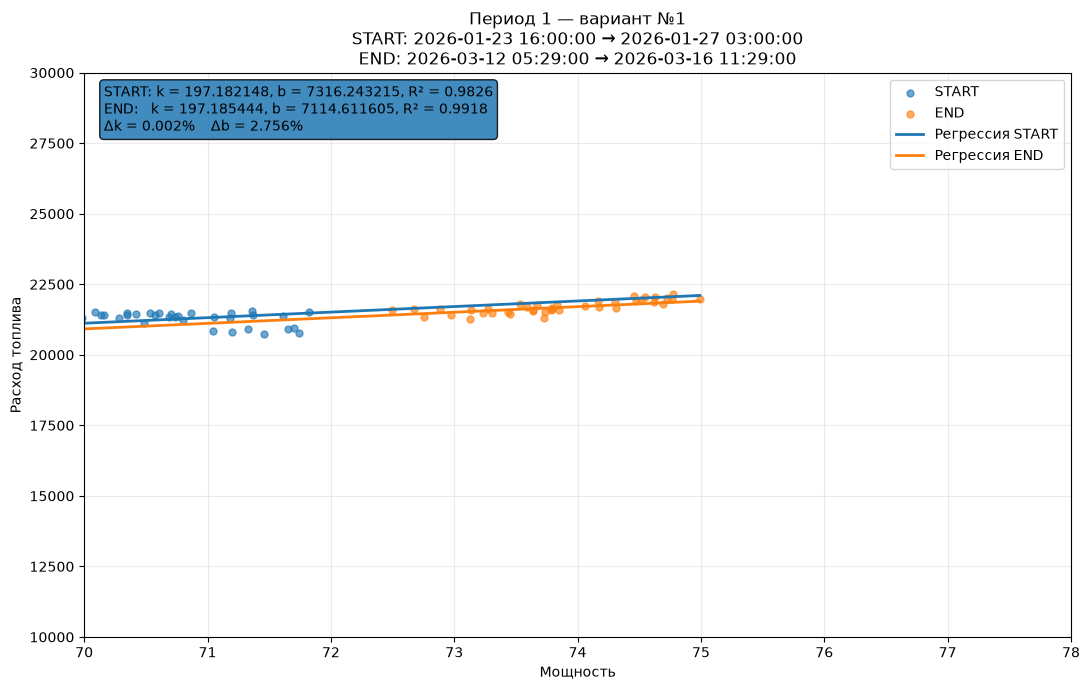

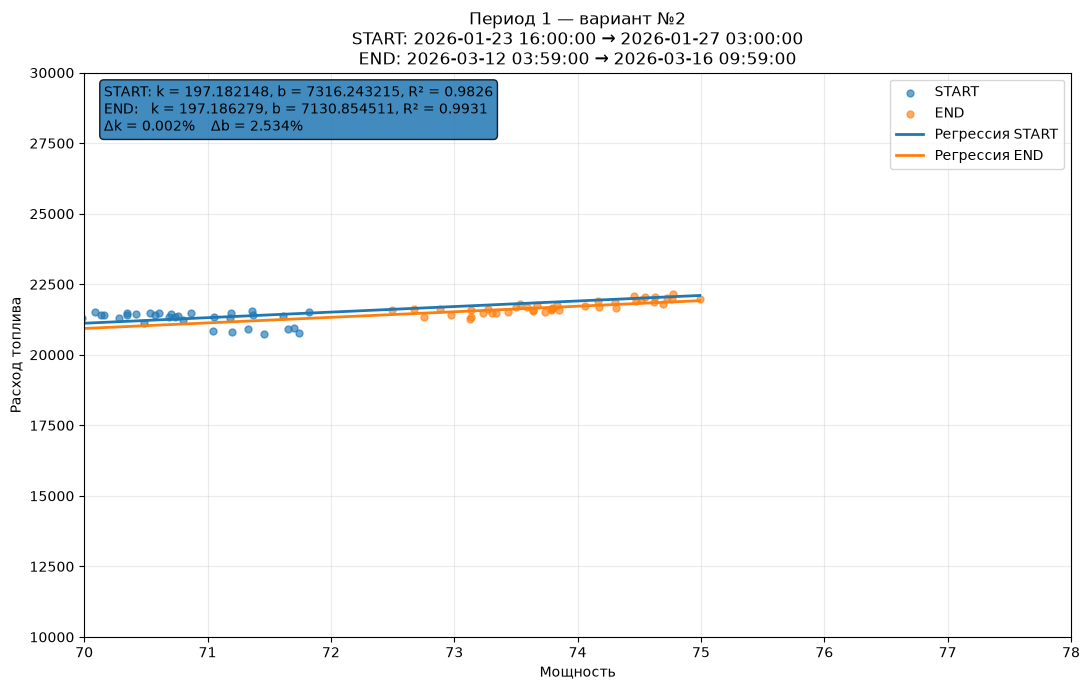

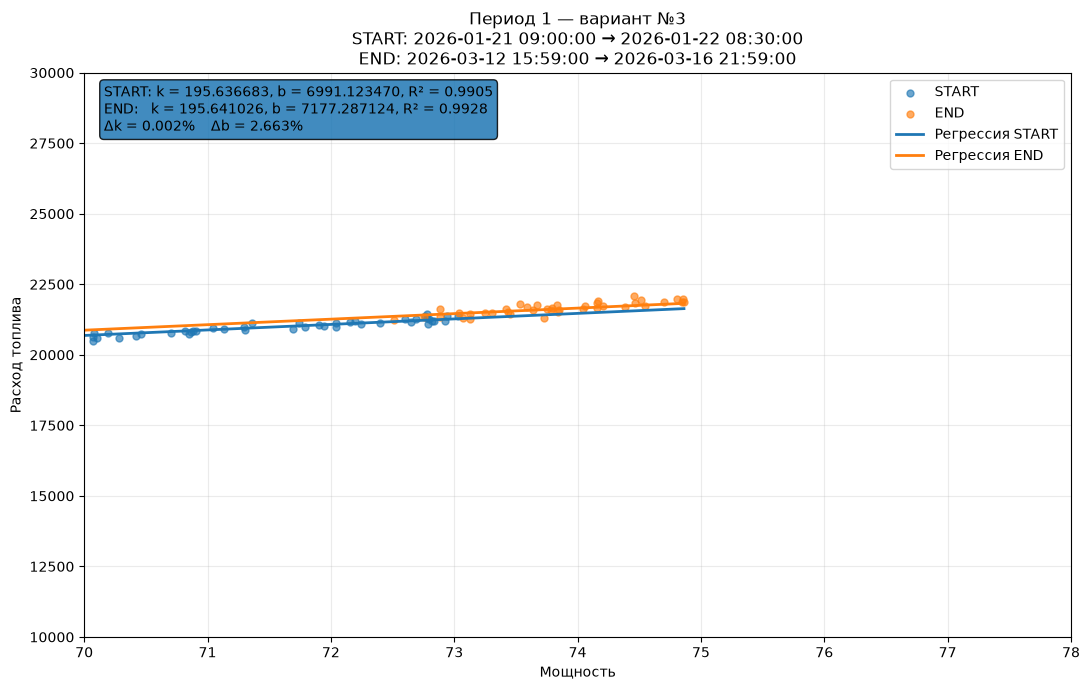

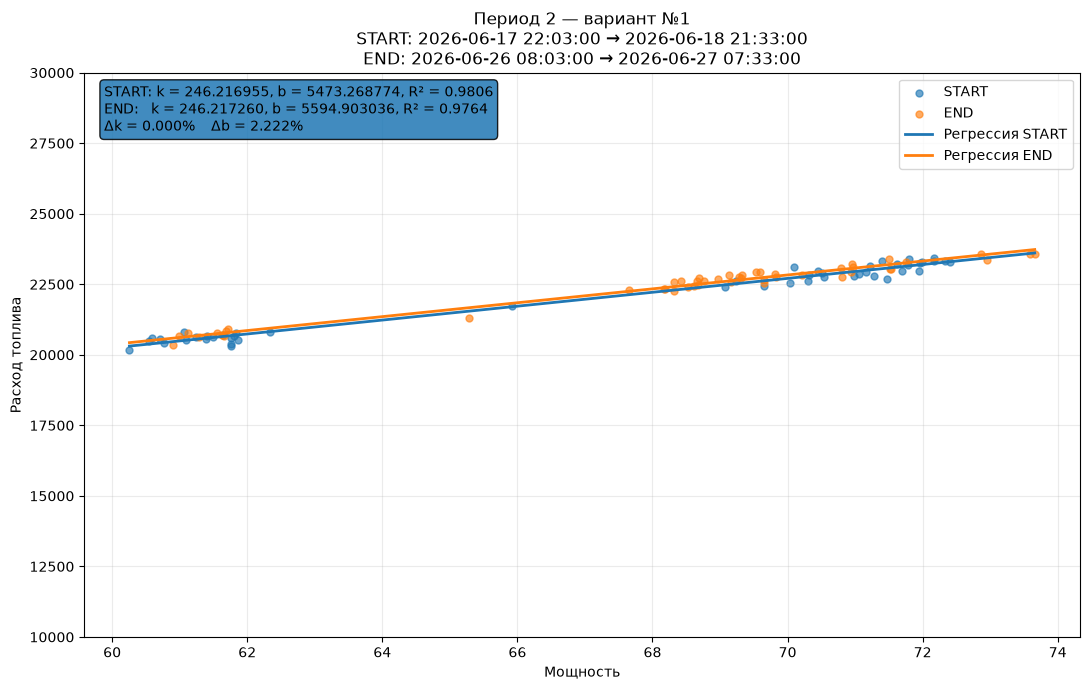

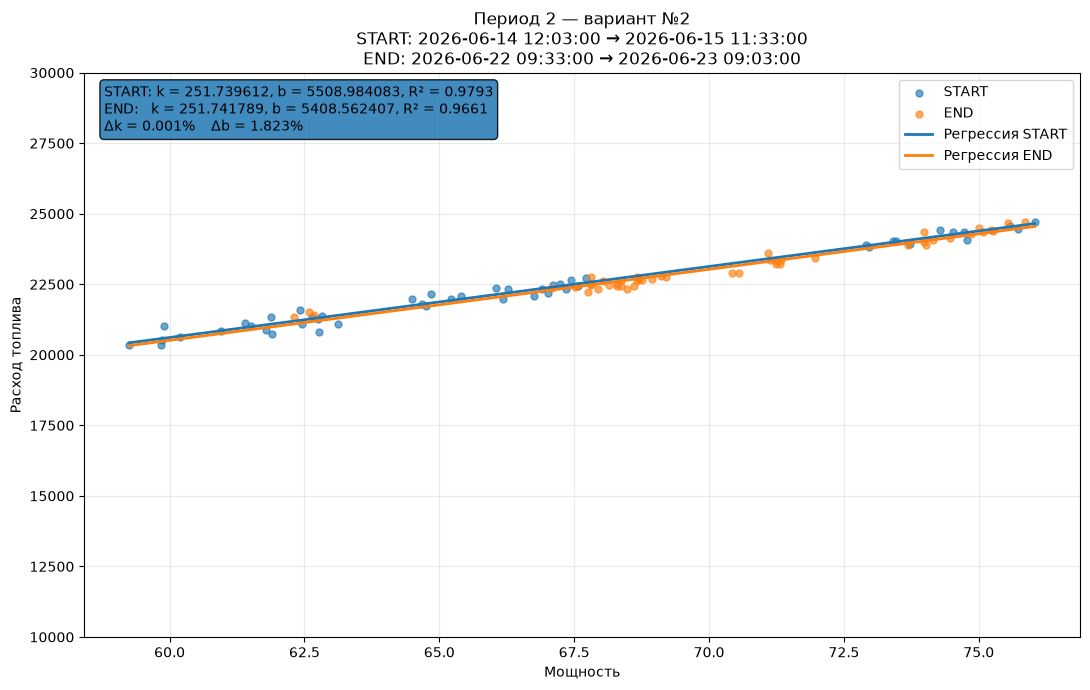

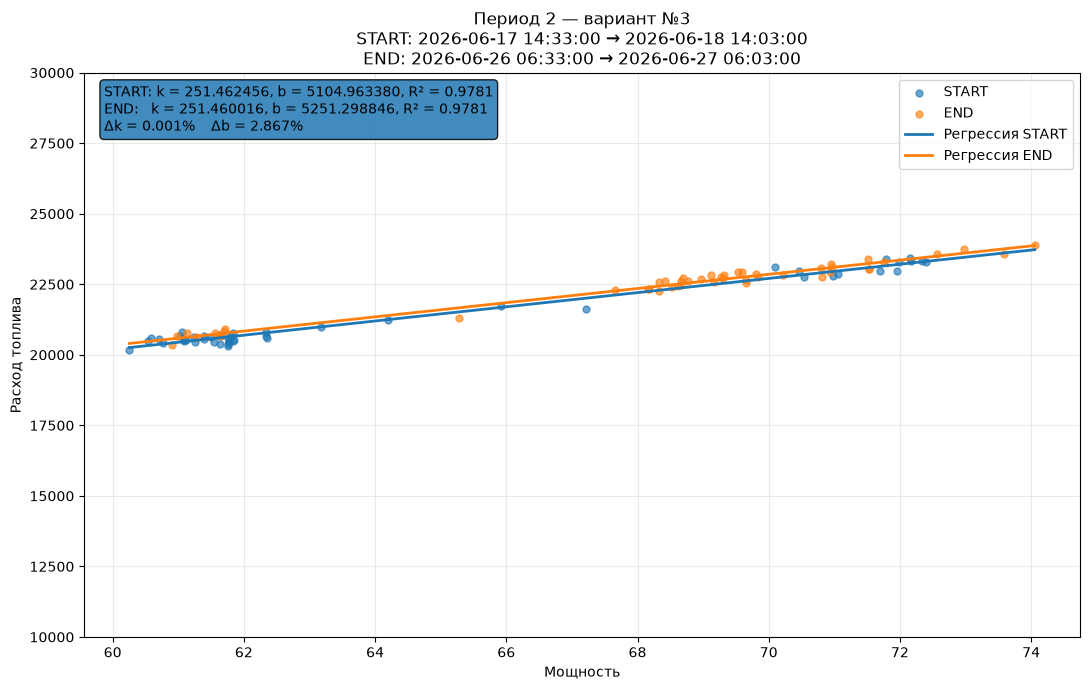

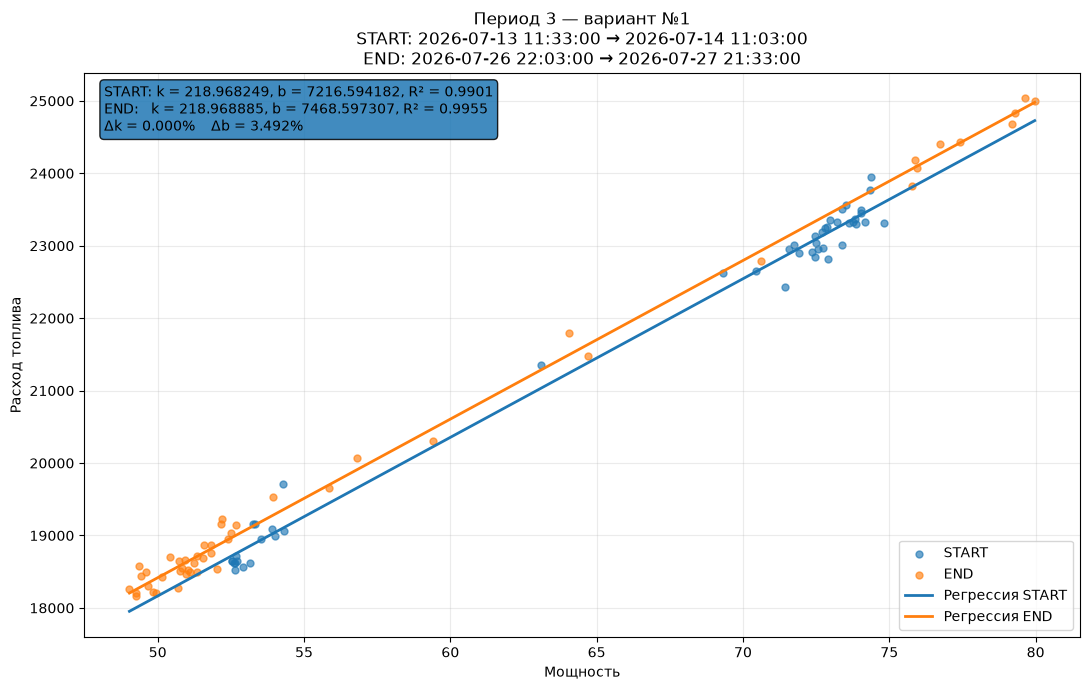

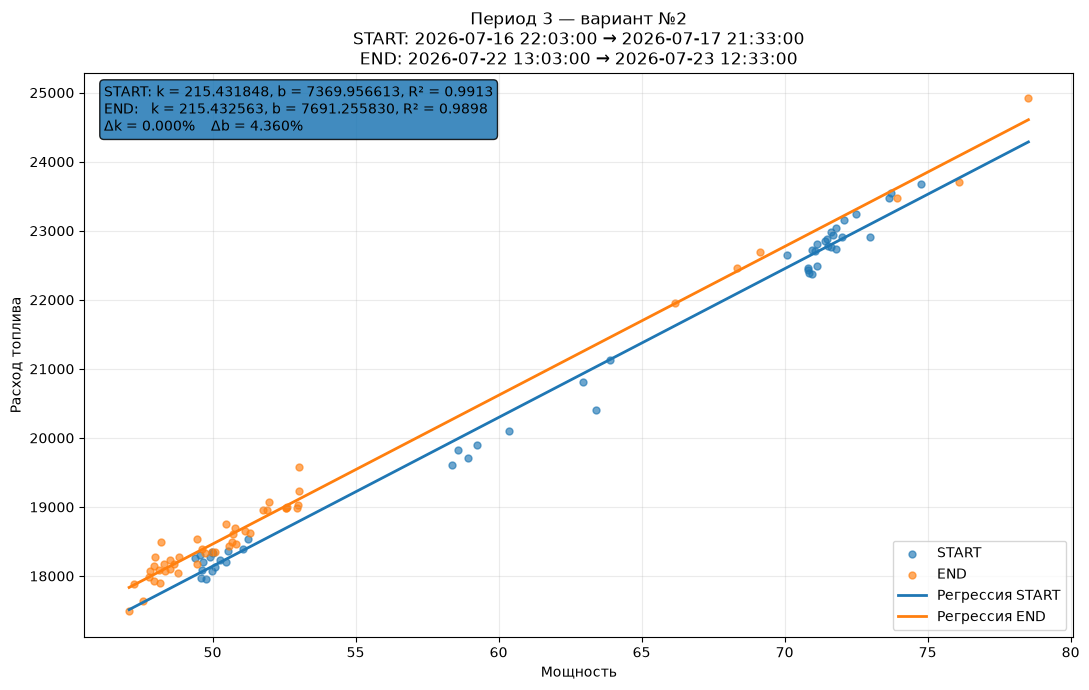

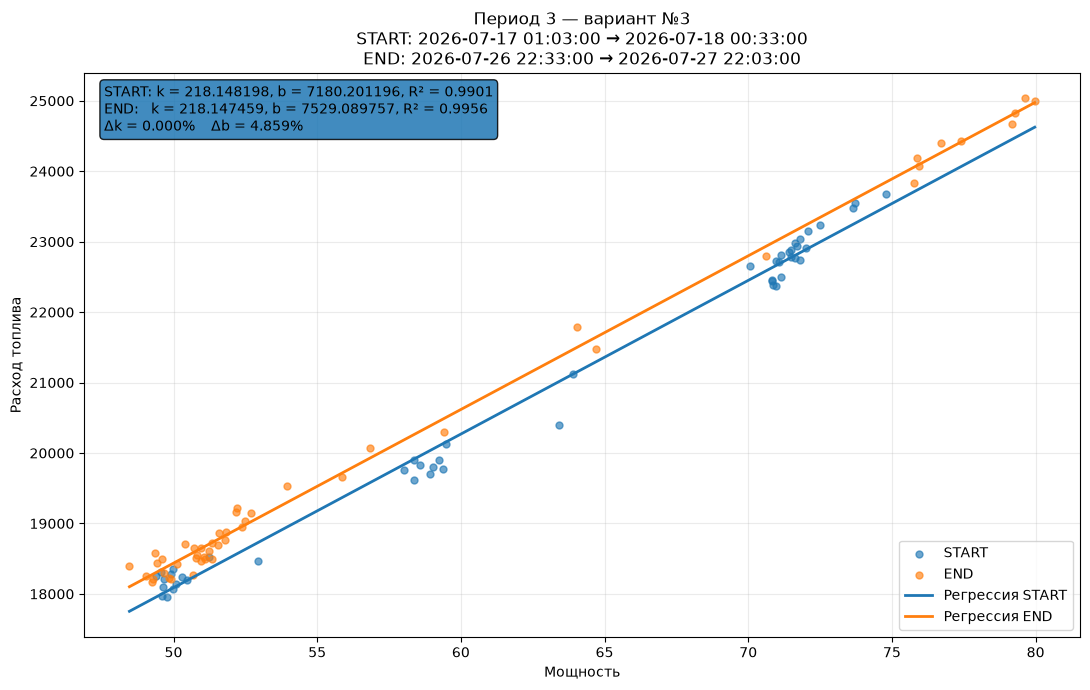

In [5]:
import matplotlib.pyplot as plt


# ============================================================
# НАСТРОЙКИ МАСШТАБА
#
# None = автоматический масштаб
#
# Пример:
# 1: (110000, 150000)
# означает Y от 110000 до 150000
# ============================================================

Y_LIMITS = {
    1: (10000, 30000),
    2: (10000, 30000),
}


# ============================================================
# МАСШТАБ X
#
# None = автоматический
# ============================================================

X_LIMITS = {
    1: (70, 78),
    2: None,
}


# ============================================================
# ПОСТРОЕНИЕ ГРАФИКОВ
# ============================================================

def plot_selected_windows():

    if not results:
        print("Нет найденных результатов.")
        return

    print(
        f"Построение графиков: "
        f"{len(results)} вариантов"
    )

    for result in results:

        period = result["period"]
        rank = result["rank"]

        # ====================================================
        # ДАННЫЕ ОКОН
        # ====================================================

        start_begin = result["start_window_begin"]
        start_end = result["start_window_end"]

        end_begin = result["end_window_begin"]
        end_end = result["end_window_end"]

        start_data = df[
            (df["period"] == period) &
            (df["date"] >= start_begin) &
            (df["date"] <= start_end)
        ].copy()

        end_data = df[
            (df["period"] == period) &
            (df["date"] >= end_begin) &
            (df["date"] <= end_end)
        ].copy()

        if start_data.empty or end_data.empty:
            print(
                f"Период {period}, вариант {rank}: "
                f"данные не найдены"
            )
            continue

        # ====================================================
        # КОЭФФИЦИЕНТЫ РЕГРЕССИИ
        # ====================================================

        k_start = result["k_start"]
        b_start = result["b_start"]

        k_end = result["k_end"]
        b_end = result["b_end"]

        # ====================================================
        # ГРАФИК
        # ====================================================

        fig, ax = plt.subplots(
            figsize=(11, 7)
        )

        # START
        ax.scatter(
            start_data["power"],
            start_data["fuel"],
            s=25,
            alpha=0.65,
            label="START"
        )

        # END
        ax.scatter(
            end_data["power"],
            end_data["fuel"],
            s=25,
            alpha=0.65,
            label="END"
        )

        # ====================================================
        # РЕГРЕССИИ
        # ====================================================

        all_power = pd.concat([
            start_data["power"],
            end_data["power"]
        ])

        x_min = all_power.min()
        x_max = all_power.max()

        x_line = np.linspace(
            x_min,
            x_max,
            100
        )

        y_start = (
            k_start * x_line +
            b_start
        )

        y_end = (
            k_end * x_line +
            b_end
        )

        ax.plot(
            x_line,
            y_start,
            linewidth=2,
            label="Регрессия START"
        )

        ax.plot(
            x_line,
            y_end,
            linewidth=2,
            label="Регрессия END"
        )

        # ====================================================
        # РУЧНОЙ / АВТОМАТИЧЕСКИЙ Y
        # ====================================================

        if Y_LIMITS.get(period) is not None:

            ax.set_ylim(
                Y_LIMITS[period][0],
                Y_LIMITS[period][1]
            )

        # ====================================================
        # РУЧНОЙ / АВТОМАТИЧЕСКИЙ X
        # ====================================================

        if X_LIMITS.get(period) is not None:

            ax.set_xlim(
                X_LIMITS[period][0],
                X_LIMITS[period][1]
            )

        # ====================================================
        # ПОДПИСИ
        # ====================================================

        ax.set_xlabel("Мощность")
        ax.set_ylabel("Расход топлива")

        ax.set_title(
            f"Период {period} — вариант №{rank}\n"
            f"START: {start_begin} → {start_end}\n"
            f"END: {end_begin} → {end_end}"
        )

        # ====================================================
        # ИНФОРМАЦИЯ
        # ====================================================

        text = (
            f"START: k = {k_start:.6f}, "
            f"b = {b_start:.6f}, "
            f"R² = {result['R2_start']:.4f}\n"
            f"END:   k = {k_end:.6f}, "
            f"b = {b_end:.6f}, "
            f"R² = {result['R2_end']:.4f}\n"
            f"Δk = {result['delta_k_pct']:.3f}%    "
            f"Δb = {result['delta_b_pct']:.3f}%"
        )

        ax.text(
            0.02,
            0.98,
            text,
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                alpha=0.85
            )
        )

        ax.grid(
            True,
            alpha=0.25
        )

        ax.legend()

        plt.tight_layout()
        plt.show()


plot_selected_windows()